# Cross-correlation
Cross-correlation measures the temporal relationship between the firing of two neurons. It is useful to identify synchronization phenomena at the network level.

In [1]:
# Import libraries
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.sparse import issparse

def plot_spike_train(peak_train, sfreq, ax):
    """
    Plot a spike train.

    Parameters:
    peak_train (numpy array): Spike train data.
    sfreq (float): Sampling frequency in Hz.
    ax (matplotlib.axes.Axes): Axes object for plotting.

    Returns:
    None
    """
    time_axis = np.arange(peak_train.size) / sfreq
    ax.plot(time_axis, peak_train, lw=.1, color='k', label='Spike')
    ax.set(xlabel='Time (s)', ylabel='Spike')
    ax.set_yticks([])
    ax.spines[['top', 'right']].set_visible(False)

## Load and plot data

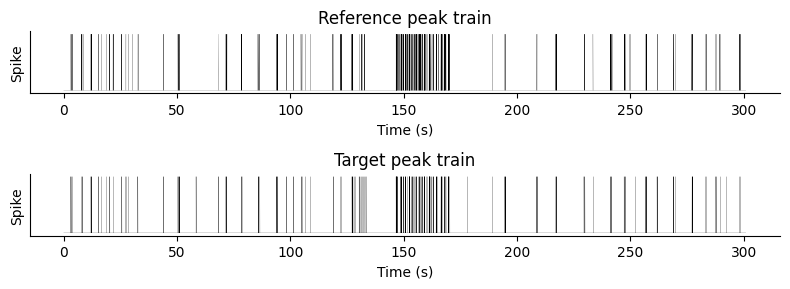

In [2]:
reference = scipy.io.loadmat('ptrain_620_DIV34_01_nbasal1_1_12.mat')['peak_train']
target = scipy.io.loadmat('ptrain_620_DIV34_01_nbasal1_1_14.mat')['peak_train']

# Ensure reference and target are dense arrays
def to_dense_array(data):
    """
    Convert sparse data to dense array if necessary.

    Parameters:
    data (scipy.sparse.csr_matrix or numpy.ndarray): Input data.

    Returns:
    numpy.ndarray: Dense array representation of the input data.
    """
    if issparse(data):
        return data.toarray().flatten()  # Convert to dense and flatten to 1D if necessary
    else:
        return np.asarray(data).flatten()

reference = to_dense_array(reference)
target = to_dense_array(target)

reference[reference > 0] = 1
target[target > 0] = 1

# Sampling frequency
sfreq = 10_000

# Plot the data
fig, axs = plt.subplots(2, 1, figsize=(8, 3))

plot_spike_train(reference, sfreq, axs[0])
axs[0].set_title('Reference peak train')
plot_spike_train(target, sfreq, axs[1])
axs[1].set_title('Target peak train')

fig.tight_layout()

## Cross-correlation implementation
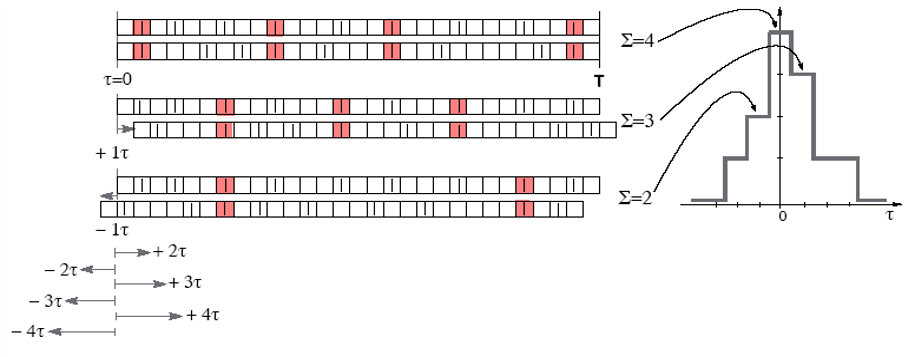

In [3]:
def compute_cross_correlation(reference, target, tau, dtau, sfreq):
    """
    Compute cross-correlation between two spike trains.

    Parameters:
    reference (numpy array): Reference spike train.
    target (numpy array): Target spike train.
    tau (float): Time delay for cross-correlation.
    dtau (float): Time step for cross-correlation.
    sfreq (float): Sampling frequency in Hz.

    Returns:
    numpy array: Cross-correlation values.
    """
    tau_s = int(tau * sfreq)
    dtau_s = int(dtau * sfreq)
    tau_axis_s = np.arange(-tau_s, tau_s + dtau_s, dtau_s)
    cross_corr = np.zeros_like(tau_axis_s)

    ref_spikes_idx = np.nonzero(reference)[0]
    for spike_idx in ref_spikes_idx:
        wdw = np.arange(max(0, spike_idx - tau_s), max(0, spike_idx - tau_s) + dtau_s, 1)
        for wdw_idx in range(2*tau_s//dtau_s):
            if wdw[-1] >= target.size:
                break
            cross_corr[wdw_idx] += sum(target[wdw])
            wdw += dtau_s
    
    cross_corr = cross_corr / np.sqrt(np.sum(reference) * np.sum(target))

    return cross_corr

dtau = 5 * 1e-3
tau = 1500 * 1e-3

tau_axis = np.arange(-tau, tau + dtau, dtau)

cross_corr = compute_cross_correlation(reference, target, tau, dtau, sfreq)

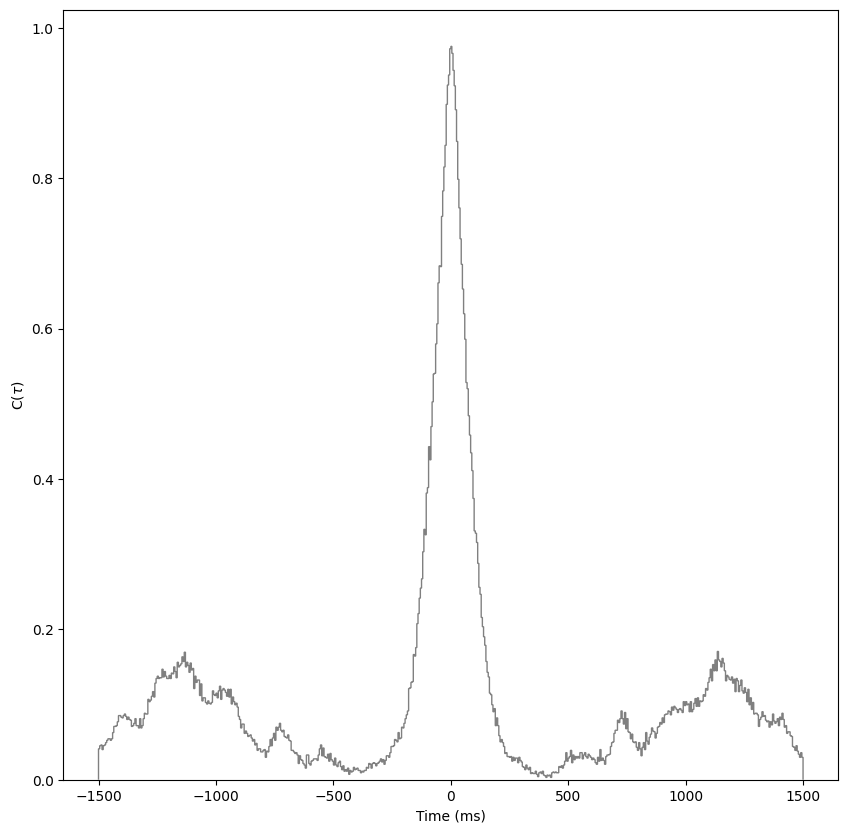

In [4]:
def plot_crosscorrelogram(xaxis, cross_corr, ax):
    """
    Plot the cross-correlogram as a bar graph.

    Parameters:
    xaxis (numpy array): Time axis values.
    cross_corr (numpy array): Cross-correlation values.
    ax (matplotlib.axes.Axes): Axes object for plotting.

    Returns:
    None
    """
    samples_axis = (xaxis * 1e3).astype(int) # Convert to ms
    ax.stairs(cross_corr[:-1], samples_axis, color='grey')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel(r'C($\tau$)')
    

# Plot the cross-correlogram
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
plot_crosscorrelogram(tau_axis, cross_corr, ax)